# Model využití revolvingové úvěrové linky pro malé podniky

## Shrnutí pro vedení

Revolvingové úvěrové linky jsou přislíbené, ale ne plně vyčerpané, takže **financovaný zůstatek** věřitele — a ekonomický kapitál, který k němu musí držet — závisí na tom, kolik z každé linky dlužník skutečně využije. Tato analýza modeluje **míru využití** (vyčerpaný zůstatek / přislíbený limit) na pracovním vzorku **100 revolvingových linek pro malé podniky** za účelem předpovědi financované expozice a podpory kapitálového plánování.

Kombinujeme čtyři procedury SAS, z nichž každá odpovídá na samostatnou plánovací otázku:

- **PROC MEANS** profiluje vyčerpaný zůstatek a využití podle interní **rizikové třídy**. Průměrné využití monotónně roste napříč třídami — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E) — čímž se stanovuje empirický vztah mezi úvěrovou kvalitou a čerpáním, který je vstupem pro předpoklady expozice při selhání.
- **PROC REG** modeluje míru využití v závislosti na fundamentálních ukazatelích dlužníka (krytí dluhové služby, volatilita tržeb, stáří linky, předchozí využití) a na makroprostředí (nezaměstnanost, krátkodobá sazba). Model vysvětluje 45 % rozptylu (R-Square 0.448, F p < .0001) a standardizované odhady řadí **krytí dluhové služby** (-0.45) a **předchozí využití** (0.41) mezi dominantní faktory. Všechny faktory inflace rozptylu zůstávají pod 1.17, takže kolinearita není problém.
- **PROC GLM** testuje, zda se využití liší podle **odvětvového segmentu** po zohlednění těchto faktorů, s využitím Tukeyho upravených průměrů nejmenších čtverců. Efekt odvětví je celkově hraniční (F p = 0.060), ale **Stavebnictví** čerpá výrazně více než **Maloobchod** (p = 0.007) a **Zdravotnictví** (p = 0.024), jakmile je kvalita dlužníka udržována konstantní.
- **PROC UNIVARIATE** extrahuje 2.5. a 97.5. percentil využití — pásmo **0.121 až 0.744** kolem průměru 0.404 — čímž definuje pravděpodobný scénář nízkého/vysokého čerpání pro zátěžové testování a testování ekonomického kapitálu.

Společně tyto výsledky umožňují bance převést statickou knihu přislíbených limitů na **výhledovou předpověď financovaného zůstatku** s obhajitelnými a auditovatelnými předpoklady. Vzorek 100 linek je výsek, který toto prostředí zpracovává; stejný program se beze změny škáluje na celou produkční knihu.

## Zdroje dat

Datová sada je generována synteticky uvnitř notebooku (žádné externí soubory, žádná síť). Každý řádek představuje jednu revolvingovou úvěrovou linku malého podniku pozorovanou v určitém okamžiku.

| Proměnná | Typ | Popis |
|----------|------|-------------|
| `id_linky` | Num | Jedinečný identifikátor úvěrové linky |
| `rizikova_trida` | Char | Interní riziková třída (A nejlepší … E nejslabší) |
| `odvetvi` | Char | Odvětvový segment dlužníka (Maloobchod, Služby, Stavebnictví, Výroba, Zdravotnictví) |
| `limit_prislibeny` | Num | Přislíbená výše úvěrové linky ($000s) |
| `stari_linky` | Num | Stáří linky (měsíce od poskytnutí) |
| `dscr` | Num | Poměr krytí dluhové služby |
| `volatilita_trzeb` | Num | Klouzavá volatilita tržeb (variační koeficient) |
| `predchozi_vyuziti` | Num | Míra využití v předchozím období (0–1) |
| `nezamestnanost` | Num | Místní míra nezaměstnanosti (%) k datu pozorování |
| `kratkodoba_sazba` | Num | Převládající krátkodobá referenční sazba (%) |
| `mira_vyuziti` | Num | Vyčerpaný zůstatek / přislíbený limit (0–1), modelovaná odezva |
| `cerpany_zustatek` | Num | Financovaný zůstatek = mira_vyuziti × limit_prislibeny ($000s) |

**Rozsah:** krok DATA je napsán tak, aby generoval celou knihu, ale toto prostředí běží bez licence a omezuje výstup na prvních **100 linek** — pracovní vzorek analyzovaný v celém dokumentu. Těchto 100 linek pokrývá všech 5 rizikových tříd (A–E) a všech 5 odvětvových segmentů. Využití je simulováno z latentní proměnné napojené přes logit řízené výše uvedenými kovariáty plus šum, takže regrese a GLM odhalují skutečný, interpretovatelný signál. Doba běhu je výrazně pod 60 sekund.

## 1. Vygenerování syntetického portfolia úvěrových linek

První buňka sestavuje realistickou knihu revolvingových linek malých podniků (toto prostředí omezuje běh na prvních **100 linek**). Pro každou linku losujeme rizikovou třídu a odvětvový segment, poté simulujeme fundamentální ukazatele dlužníka a makroprostředí. Využití je generováno z **latentního skóre napojeného přes logit**, takže slabší třídy, nižší krytí dluhové služby, vyšší volatilita tržeb, houževnatější předchozí využití a stresované makroekonomické pozadí — to vše tlačí vyčerpaný podíl nahoru — přesně ta struktura, kterou mají regrese a GLM níže odhalit. Financovaný `cerpany_zustatek` je pak využití krát přislíbený limit.

In [1]:
/* --------------------------------------------------------
   Vygenerování syntetického portfolia revolvingových
   úvěrových linek malých podniků. Využití je simulováno
   z latentní proměnné napojené přes logit, řízené úvěrovými,
   dlužnickými a makroekonomickými kovariáty, aby modely
   níže odhalily skutečný signál.
   -------------------------------------------------------- */
data uverove_linky;
    call streaminit(20260605);

    ŠTÍTEK id_linky         = "Identifikátor úvěrové linky"
          rizikova_trida    = "Interní riziková třída (A-E)"
          odvetvi           = "Odvětvový segment dlužníka"
          limit_prislibeny  = "Přislíbený limit ($000s)"
          stari_linky       = "Stáří linky (měsíce)"
          dscr              = "Poměr krytí dluhové služby"
          volatilita_trzeb  = "Volatilita tržeb (VK)"
          predchozi_vyuziti = "Míra využití v předchozím období"
          nezamestnanost    = "Místní míra nezaměstnanosti (%)"
          kratkodoba_sazba  = "Krátkodobá referenční sazba (%)"
          mira_vyuziti      = "Míra využití (čerpáno/limit)"
          cerpany_zustatek  = "Financovaný zůstatek ($000s)";

    /* Vyhledávací pole pro kategoriální atributy */
    POLE tridy[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    POLE segmenty[5] $20 _temporary_
        ('Maloobchod' 'Služby' 'Stavebnictví'
         'Výroba' 'Zdravotnictví');

    OPAKUJ id_linky = 1 to 4000;

        /* Riziková třída: více hmoty ve středních třídách */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        rizikova_trida = tridy[g];

        /* Odvětvový segment: zhruba rovnoměrně s náklonem k maloobchodu */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        odvetvi = segmenty[s];

        /* Přislíbený limit: log-normální, $25k až ~$1,5M */
        limit_prislibeny = round(25 + exp(rand('NORMAL', 4.6, 0.55)), 1);

        /* Fundamentální ukazatele dlužníka */
        stari_linky       = round(rand('UNIFORM') * 84 + 3, 1);
        dscr              = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        volatilita_trzeb  = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        predchozi_vyuziti = min(0.98, max(0.02,
                             rand('BETA', 2, 3)));

        /* Makroprostředí k datu pozorování */
        nezamestnanost = round(rand('NORMAL', 5.2, 1.1), 0.1);
        KDYŽ nezamestnanost < 2.5 PAK nezamestnanost = 2.5;
        kratkodoba_sazba = round(rand('NORMAL', 4.0, 0.8), 0.01);
        KDYŽ kratkodoba_sazba < 0 PAK kratkodoba_sazba = 0;

        /* Index závažnosti třídy: A=0 ... E=4 */
        zavaznost_tridy = g - 1;

        /* Latentní skóre využití napojené přes logit.
           Slabší třídy, nižší DSCR, vyšší volatilita,
           houževnaté předchozí čerpání a makro stres
           zvyšují využití. */
        eta = -0.60
              + 0.34 * zavaznost_tridy
              - 0.55 * (dscr - 1.4)
              + 1.10 * (volatilita_trzeb - 0.24)
              + 1.80 * (predchozi_vyuziti - 0.45)
              + 0.16 * (nezamestnanost - 5.2)
              + 0.07 * (kratkodoba_sazba - 4.0)
              - 0.004 * (stari_linky - 40);

        /* Posuny odvětvového segmentu na latentní škále */
        VYBRAT (odvetvi);
            KDYŽ_V ('Stavebnictví')  eta = eta + 0.30;
            KDYŽ_V ('Maloobchod')    eta = eta + 0.12;
            KDYŽ_V ('Výroba')        eta = eta - 0.08;
            KDYŽ_V ('Zdravotnictví') eta = eta - 0.22;
            JINAK_V; /* Služby = reference */
        KONEC;

        /* Přidání šumu, mapování na (0,1) přes logistický link */
        eta = eta + rand('NORMAL', 0, 0.45);
        mira_vyuziti = round(1 / (1 + exp(-eta)), 0.0001);

        /* Financovaný zůstatek plyne z využití */
        cerpany_zustatek = round(mira_vyuziti * limit_prislibeny,
                              0.1);

        VÝSTUP;
    KONEC;

    PONECHAT id_linky rizikova_trida odvetvi limit_prislibeny
         stari_linky dscr volatilita_trzeb predchozi_vyuziti
         nezamestnanost kratkodoba_sazba mira_vyuziti cerpany_zustatek;
SPUSTIT;


NOTE: DATA uverove_linky

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote uverove_linky (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  1.82 seconds
  cpu   1.82 seconds


## 2. Financovaná expozice podle rizikové třídy

Modely ekonomického kapitálu potřebují vědět, jak se financovaný zůstatek a využití liší napříč úvěrovou kvalitou. **PROC MEANS** shrnuje vyčerpaný zůstatek a využití pro každou interní rizikovou třídu s úplným distribučním obrazem — průměr, směrodatná odchylka, kvartily a rozpětí. Očekáváme, že využití bude monotónně stoupat od třídy A ke třídě E, což přímo informuje předpoklady o expozici při selhání pro revolvingovou knihu.

In [2]:
/* Vyčerpaný zůstatek a využití podle interní rizikové třídy */
NÁZEV "Financovaná expozice podle rizikové třídy";
PROCEDURA PRŮMĚRY data=uverove_linky NWAY maxdec=3
          n mean std min q1 median q3 max;
    TŘÍDA rizikova_trida;
    PROMĚNNÁ cerpany_zustatek mira_vyuziti limit_prislibeny;
SPUSTIT;

                                       Financovaná expozice podle rizikové třídy                                        

                                                  The MEANS Procedure

                          Analysis Variable : cerpany_zustatek Financovaný zůstatek ($000s)

        Interní riziková třída (A-E)              N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        ----------------------------------------------------------------------------------------------------------------------------------------------------------
        A                                            18         41.239         24.697          5.900          25.500         37.200          50.200        103.300
        B                                            26         43.585         25.010          7.800          25.700         33.050          62.000         99.900
        C                                            29       


NOTE: Option TITLE changed to Financovaná expozice podle rizikové třídy.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Faktory využití — vícenásobná regrese

**PROC REG** modeluje míru využití v závislosti na fundamentálních ukazatelích dlužníka a na makroprostředí. Požadujeme:

- **CLB** — 95% konfidenční meze pro každý koeficient, aby úvěrový tým mohl vykazovat rozpětí efektů namísto bodových odhadů.
- **VIF** a **TOL** — faktory inflace rozptylu a toleranci pro potvrzení, že kovariáty nejsou kolineární.
- **STB** — standardizované odhady pro seřazení faktorů na porovnatelné škále.

Koeficienty odpovídají na plánovací otázku přímo: o kolik posun jedné jednotky u každého faktoru změní očekávaný vyčerpaný podíl linky? Nafitovaný model vysvětluje 45 % rozptylu využití (R-Square 0.448, celkové F p < .0001). PROC REG také vydává svůj standardní diagnostický panel ODS — rezidua vs. predikce, histogram reziduí, rezidua vs. pořadí pozorování, normální Q-Q graf a graf vlivu Cookovy D — zobrazený pod tabulkou. Procedura je interaktivní procedura typu RUN-group, takže ji uzavíráme příkazem `quit;` pro vyprázdnění výstupu.

                                       Faktory míry využití — vícenásobná regrese                                       

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                           Dependent Variable: mira_vyuziti Míra využití (čerpáno/limit)                           

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.30923      0.21821     12.83    <.0001
Error                  93         1.58120      0.01700                    
Corrected Total        99         2.89043                                 

Root MSE           0.13039    R-Square            0.4530
Dependent Mean       0.40565    Adj R-Sq            0.4177
Coeff Var         32.14387



NOTE: Option TITLE changed to Faktory míry využití — vícenásobná regrese.
NOTE: PROC REG data=uverove_linky

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


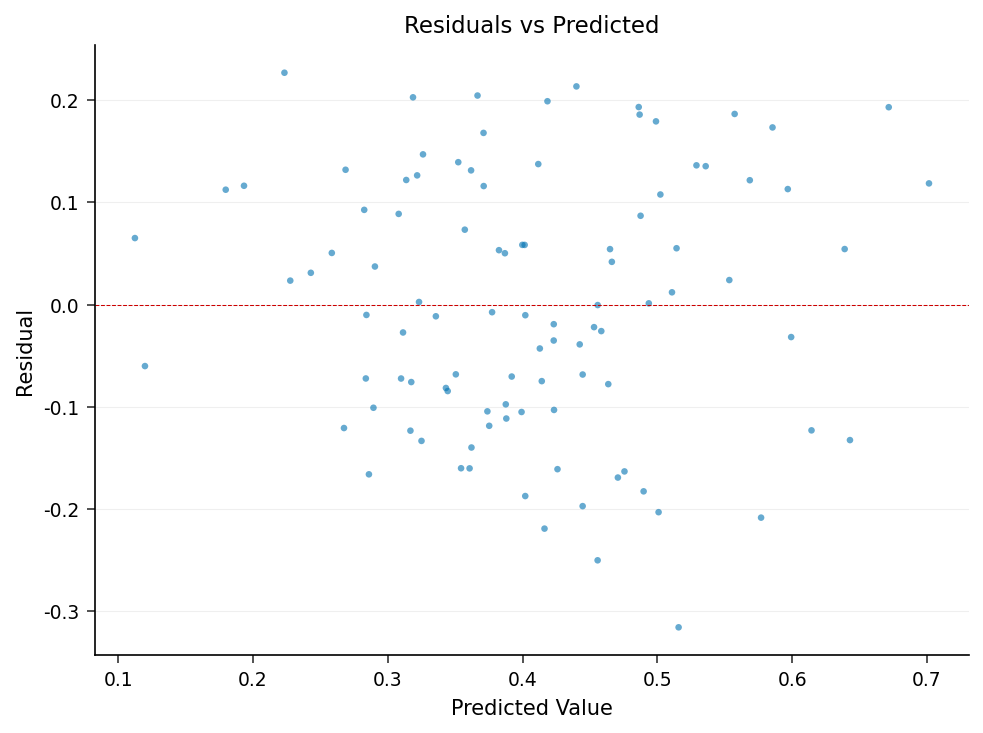

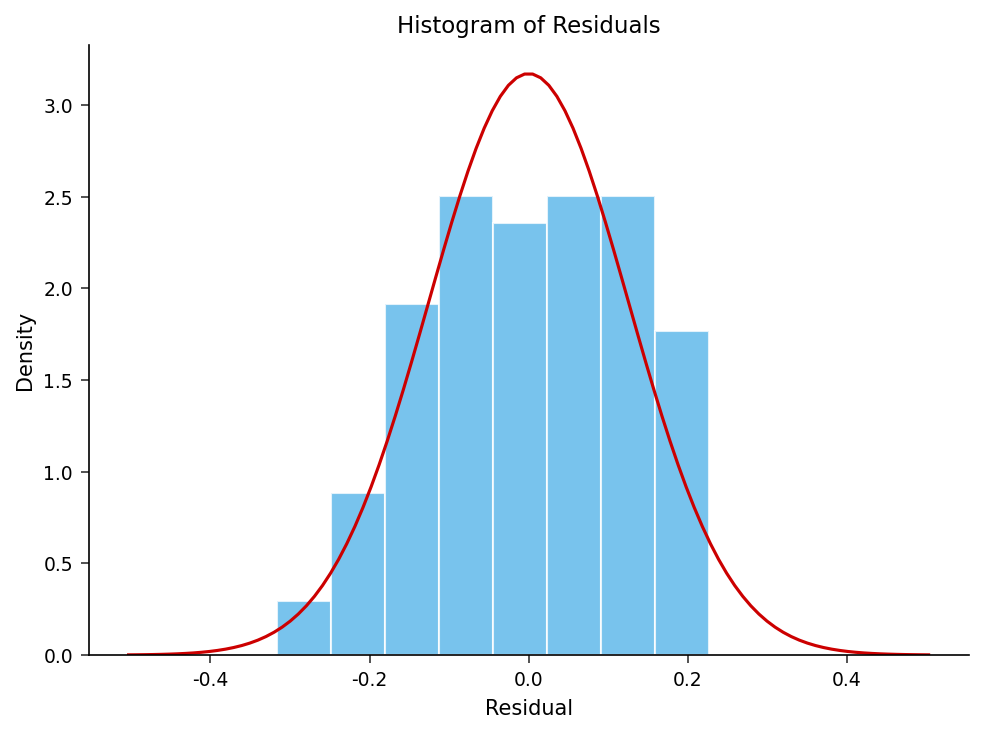

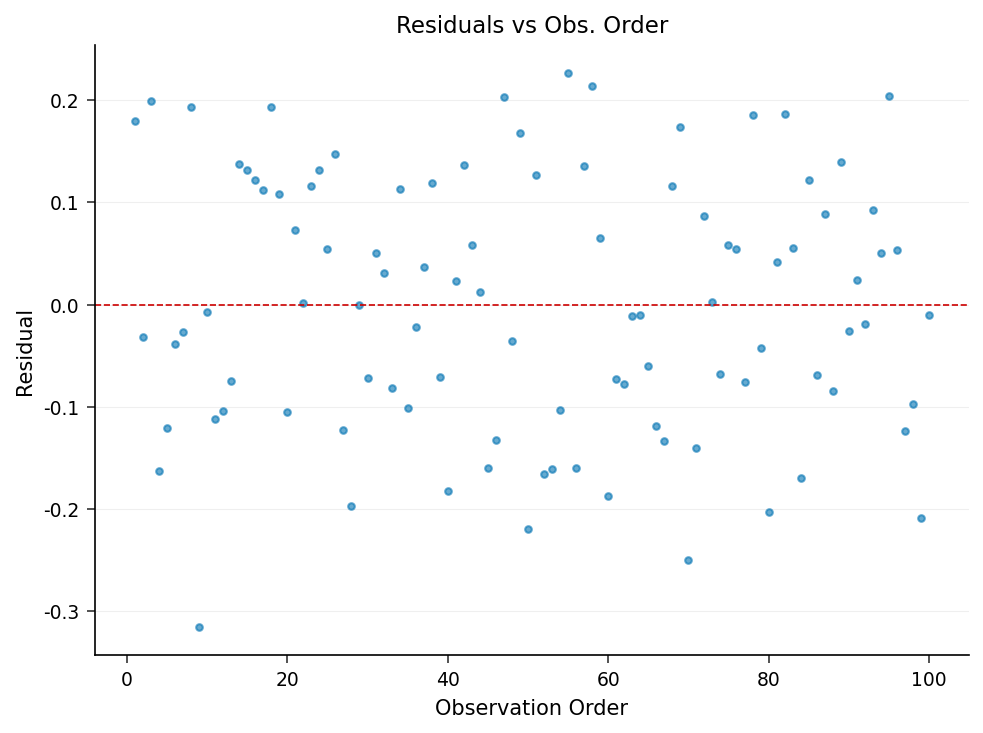

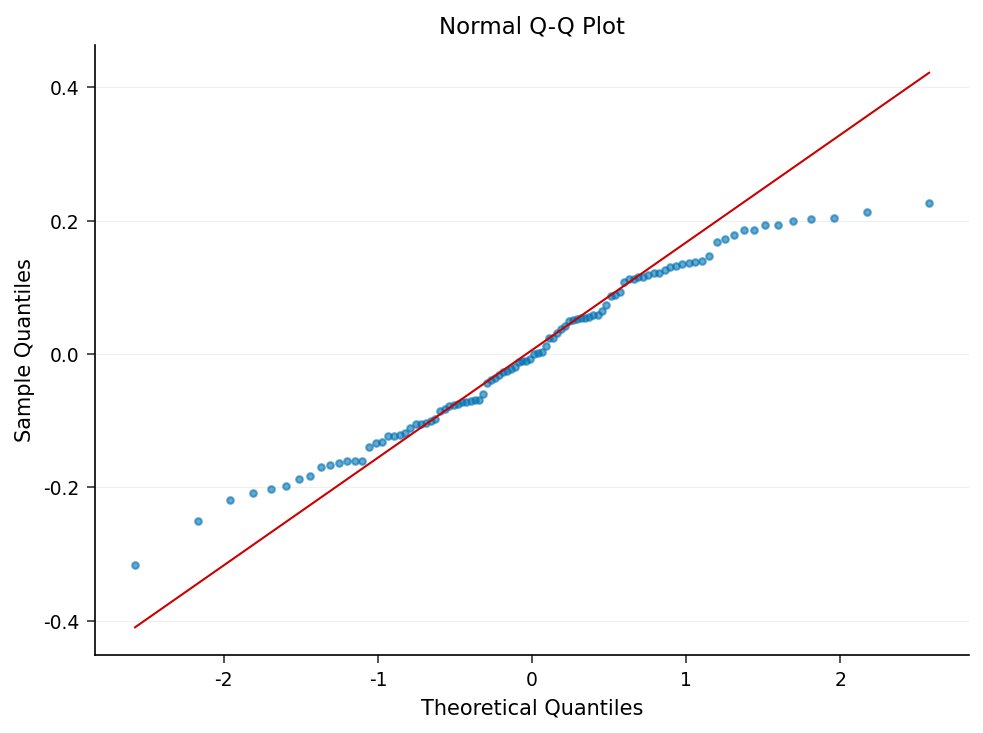

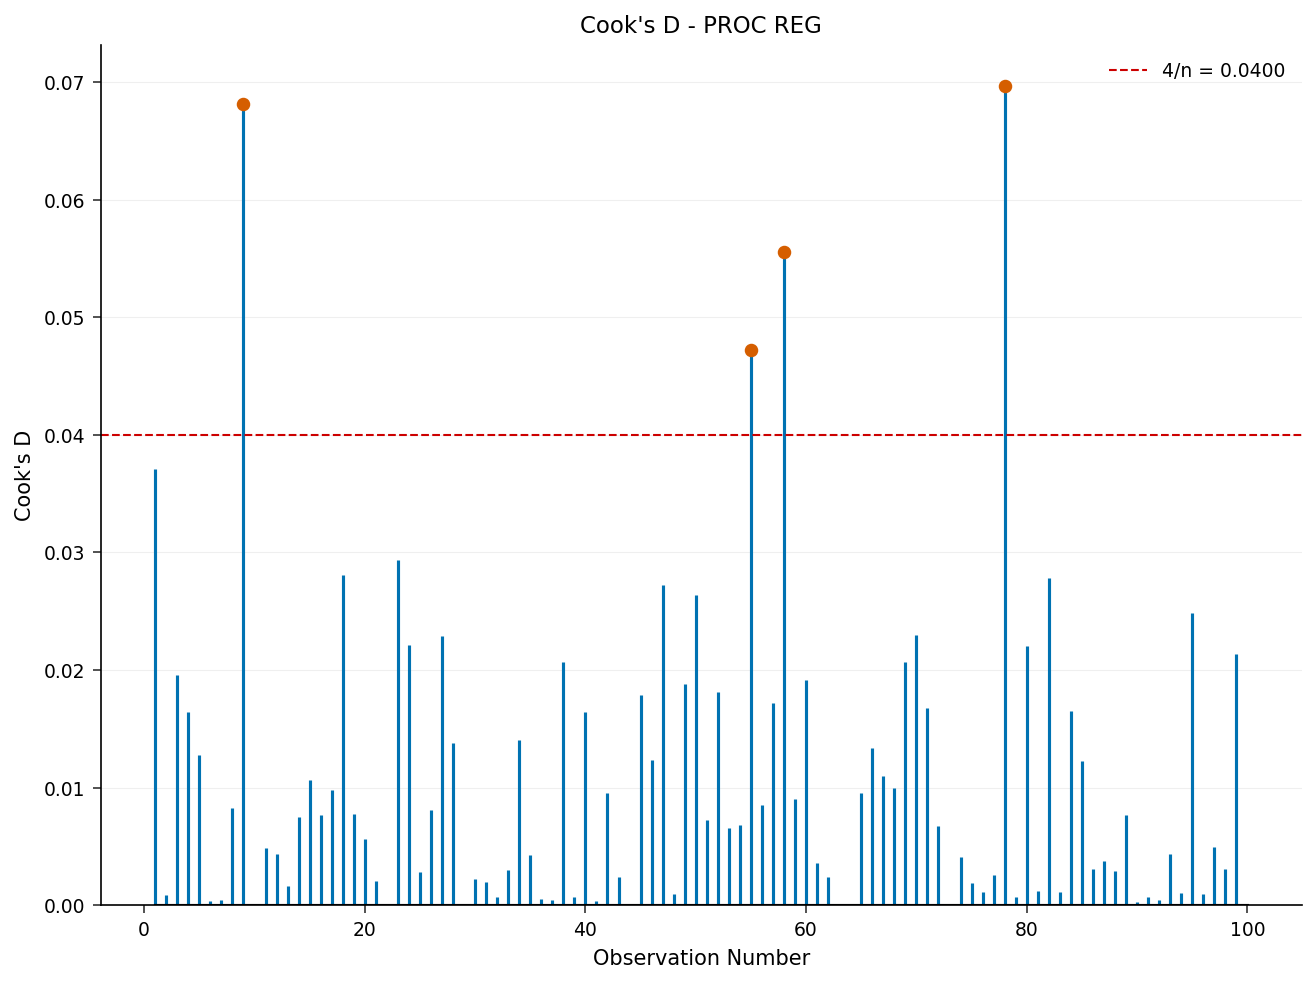

In [3]:
/* Míra využití vs. dlužnické a makroekonomické kovariáty */
NÁZEV "Faktory míry využití — vícenásobná regrese";
PROCEDURA REG data=uverove_linky;
    MODEL mira_vyuziti =
          dscr volatilita_trzeb predchozi_vyuziti
          stari_linky nezamestnanost kratkodoba_sazba
          / clb stb vif tol;
SPUSTIT;
QUIT;

## 4. Využití podle odvětvového segmentu — obecný lineární model

Čerpají některá odvětví ze svých linek agresivněji, jakmile zohledníme kvalitu dlužníka a makroekonomické pozadí? **PROC GLM** zachází s proměnnou `industry` jako s klasifikačním efektem a přidává stejné spojité kovariáty jako kontroly analýzy kovariance. Požadujeme:

- **SOLUTION** — odhady parametrů pro každou úroveň odvětví vzhledem k referenci.
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** — Tukeyho upravené průměry nejmenších čtverců a párové rozdíly, tj. kovariátami upravené využití pro každý segment.

GLM vydává stejný diagnostický panel ODS jako REG plus sloupcový graf průměrů nejmenších čtverců podle odvětví (s konfidenčními intervaly), zobrazený pod tabulkami. Je to rovněž procedura typu RUN-group, takže končí příkazem `quit;`.

                                        Míra využití podle odvětvového segmentu                                         

                             The GLM Procedure                              
     Dependent Variable: mira_vyuziti Míra využití (čerpáno/limit)     

Source                   DF  Sum of Squares  Mean Square   F Value    Pr > F
-----------------  --------  --------------  -----------  --------  --------
odvetvi                   4         0.06272      0.01568      0.91    0.4589
dscr                      1         0.66589      0.66589     38.85    <.0001
volatilita_trzeb          1         0.12682      0.12682      7.40    0.0078
predchozi_vyuziti         1         0.42159      0.42159     24.60    <.0001
nezamestnanost            1         0.13869      0.13869      8.09    0.0055
kratkodoba_sazba          1         0.08804      0.08804      5.14    0.0258
Error                    90         1.54260      0.01714                    

Root MSE           0.13092    R-Sq


NOTE: Option TITLE changed to Míra využití podle odvětvového segmentu.
NOTE: PROC GLM data=uverove_linky

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_odvetvi.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


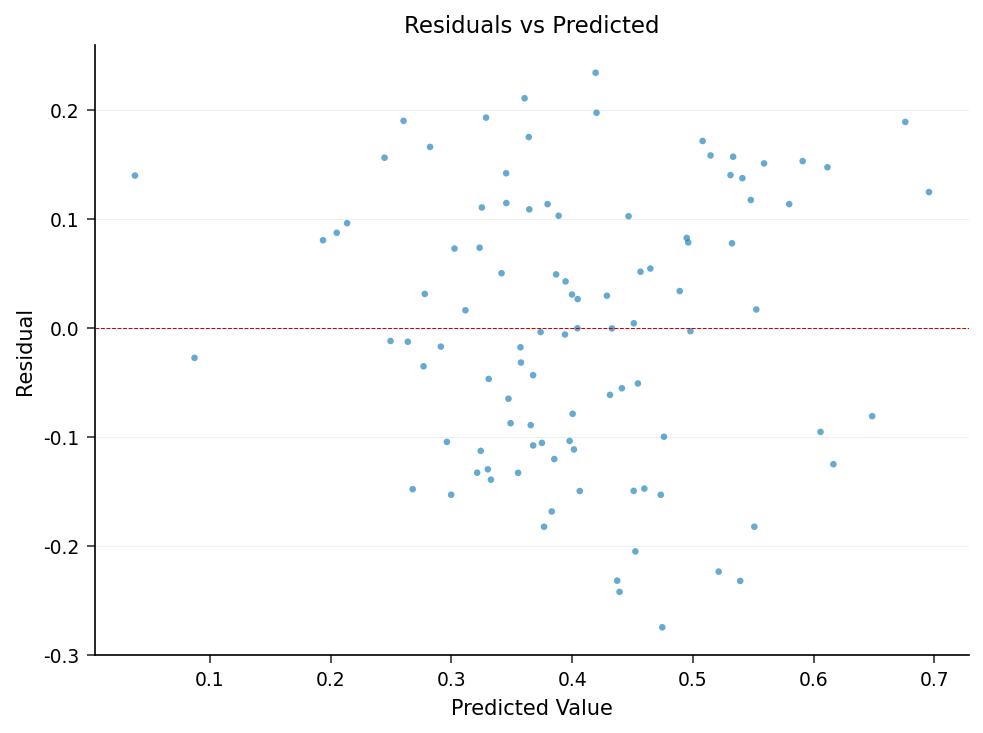

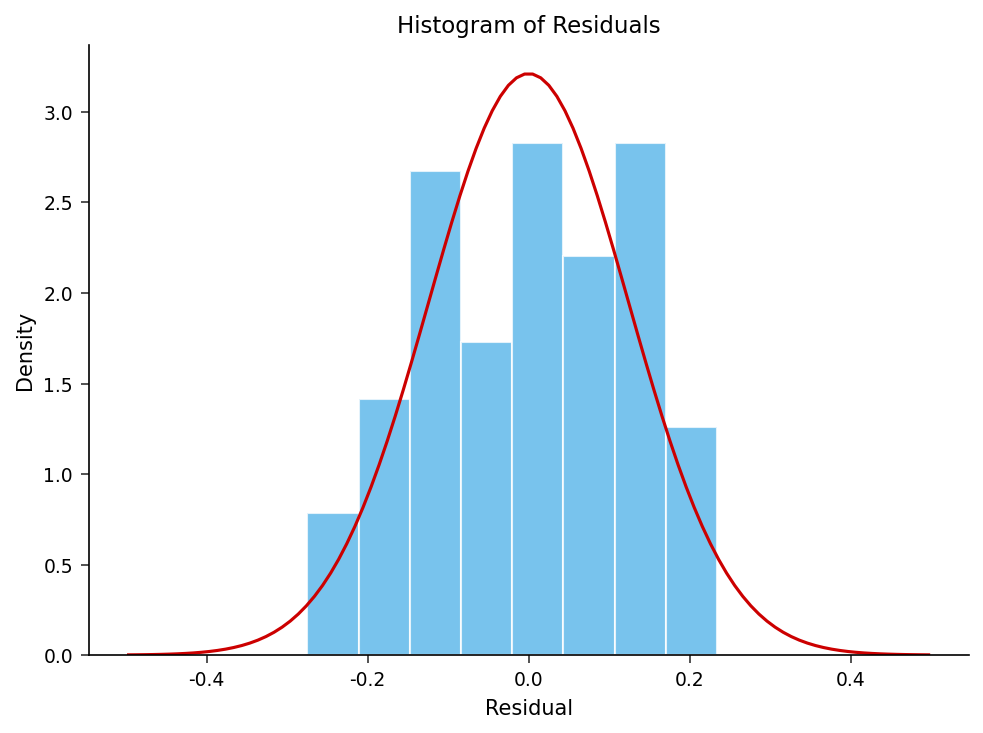

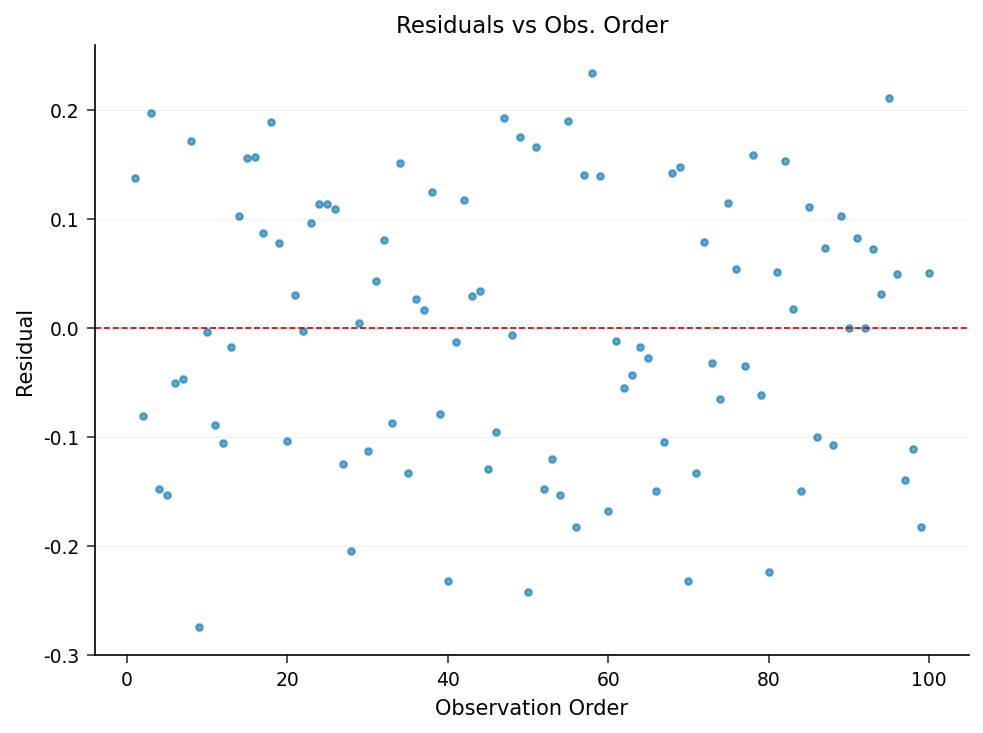

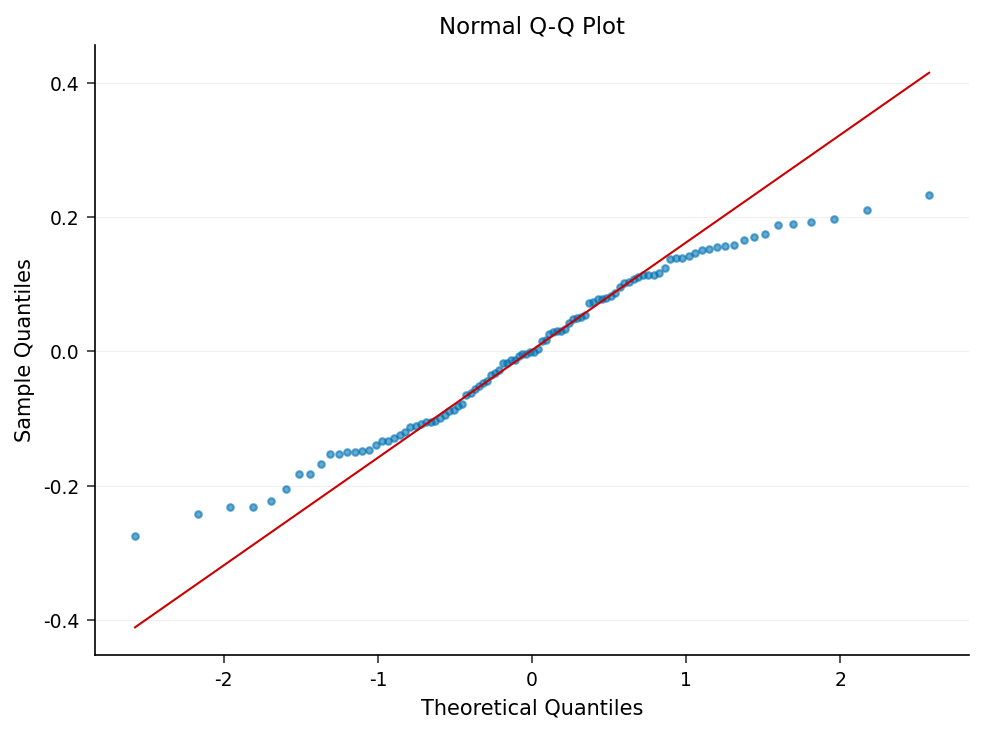

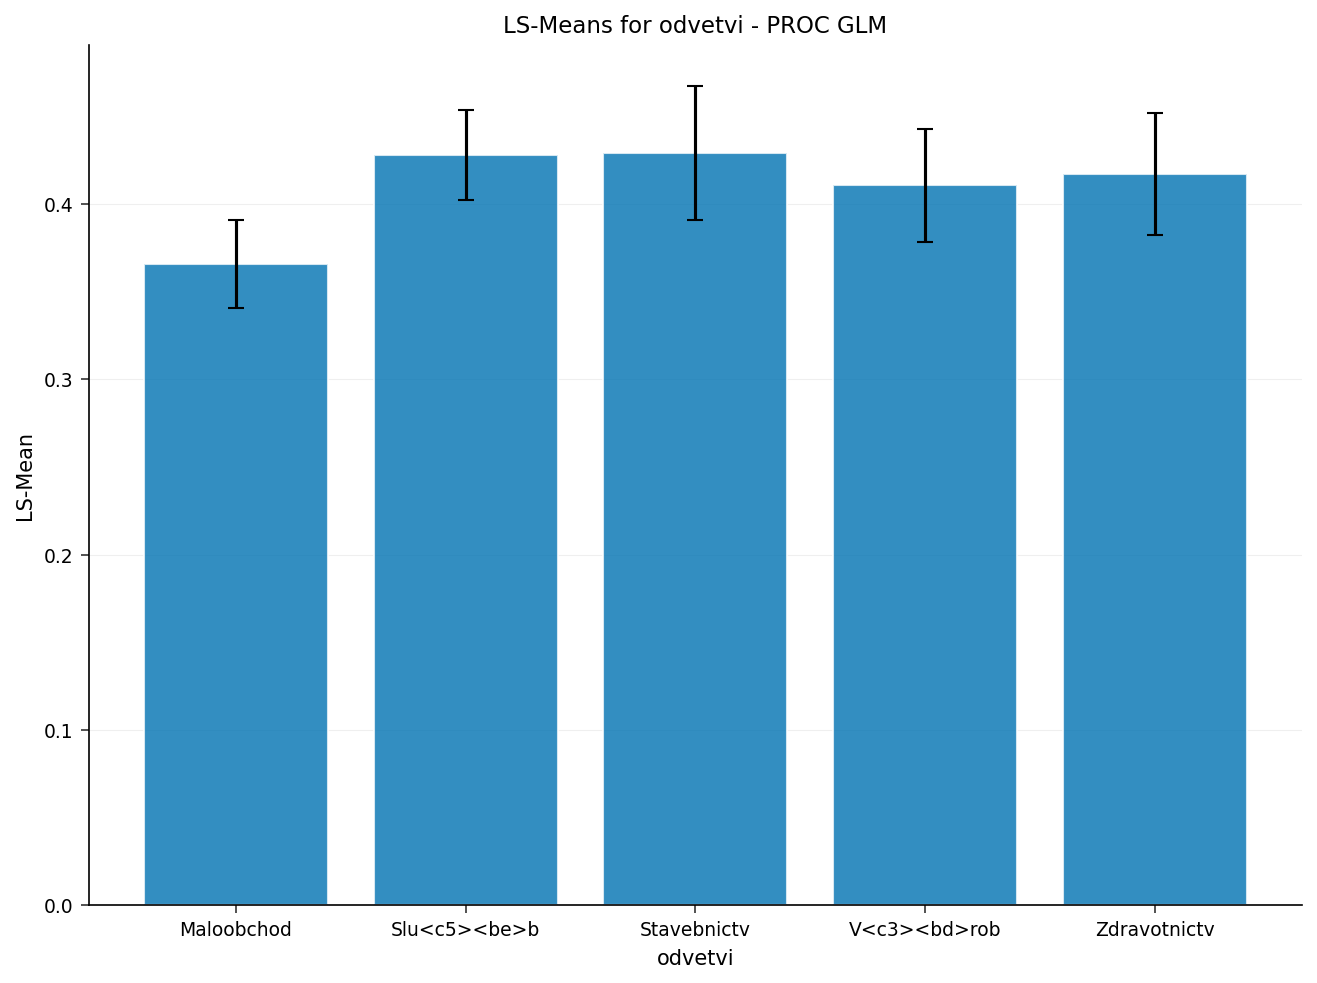

In [4]:
/* Využití podle odvětvového segmentu, s úpravou o faktory */
NÁZEV "Míra využití podle odvětvového segmentu";
PROCEDURA GLM data=uverove_linky;
    TŘÍDA odvetvi;
    MODEL mira_vyuziti =
          odvetvi dscr volatilita_trzeb predchozi_vyuziti
          nezamestnanost kratkodoba_sazba
          / SOLUTION ss3;
    LSMEANS odvetvi / PDIFF ADJUST=TUKEY cl;
SPUSTIT;
QUIT;

## 5. Pásmo využití pro zátěžové testy a ekonomický kapitál

Kapitálové plánování potřebuje **konce** distribuce využití, nejen průměr. Protože zlomkové percentily se nejlépe berou z **PROC UNIVARIATE** spíše než z PROC MEANS, používáme `PCTLPTS=` k extrakci **2.5. a 97.5. percentilu** využití. Výsledné pásmo definuje pravděpodobný scénář nízkého/vysokého čerpání pro zátěžové testování financovaného zůstatku.

In [5]:
/* 2,5. / 97,5. percentil využití pro zátěžové pásmo */
PROCEDURA UNIVARIATE data=uverove_linky NOPRINT;
    PROMĚNNÁ mira_vyuziti;
    VÝSTUP out=pasmo_vyuziti
           mean=prumer_vyuziti
           pctlpts=2.5 97.5
           pctlpre=vyuz_p
           pctlname=lo hi;
SPUSTIT;

NÁZEV "Pásmo využití pro zátěžové testy a ekonomický kapitál";
PROCEDURA TISK data=pasmo_vyuziti noobs ŠTÍTEK;
    ŠTÍTEK prumer_vyuziti = "Průměrné využití"
          vyuz_plo  = "2,5. percentil (zátěž nízká)"
          vyuz_phi  = "97,5. percentil (zátěž vysoká)";
SPUSTIT;

                                 Pásmo využití pro zátěžové testy a ekonomický kapitál                                  


     Průměrné využití       2,5. percentil (zátěž nízká)      97,5. percentil (zátěž vysoká)
---------------------  ---------------------------------  ----------------------------------
             0.405652                             0.1467                              0.7587




NOTE: PROC UNIVARIATE
NOTE: Output dataset pasmo_vyuziti has 1 observations and 3 variables.
NOTE: Option TITLE changed to Pásmo využití pro zátěžové testy a ekonomický kapitál.
NOTE: PROC PRINT data=pasmo_vyuziti

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. Interpretace a další kroky

**Co model ukazuje**

- **Riziková třída řídí financovanou expozici.** Profil z PROC MEANS ukazuje, že průměrné využití monotónně roste od nejsilnější třídy k nejslabší — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E). Protože vyčerpaný zůstatek je využití krát přislíbený limit, slabší třídy převádějí větší podíl svých závazků na financované zůstatky — klíčový vstup pro expozici při selhání a ekonomický kapitál revolvingových linek. (Průměrný vyčerpaný zůstatek rovněž stoupá s třídou a vrcholí u třídy D v tomto vzorku 100 linek; malá buňka třídy E o 9 linkách nese jeden velmi velký limit, který táhne její průměr přislíbeného limitu, což je přesně ten druh chování malých buněk, které by celá kniha vyhladila.)
- **Fundamentální ukazatele dlužníka dominují regresi.** V PROC REG má **krytí dluhové služby** největší standardizovaný koeficient (-0.45) a je ochranné — každá další jednotka krytí snižuje využití o zhruba 0.11 (95% CL -0.152 až -0.075). **Předchozí využití** je druhým nejsilnějším faktorem (standardizovaně 0.41, odhad +0.38): linky, které byly dříve silně čerpané, zůstávají vysoce využité. **Volatilita tržeb** (+0.37, p = 0.021) a makro členy — **nezaměstnanost** (+0.036, p = 0.009) a **krátkodobá sazba** (+0.036, p = 0.036) — jsou všechny kladné a významné, takže pokles mechanicky zvyšuje financované zůstatky napříč portfoliem. Všechny VIF leží pod 1.17, výrazně pod konvenčním prahem 10, což potvrzuje, že faktory nejsou kolineární, a intervaly CLB vylučují nulu u každého efektu kromě stáří linky. Diagnostika reziduí je v pořádku: rezidua se náhodně rozptylují kolem nuly, histogram je přibližně normální a Q-Q graf je blízký linearitě jen s mírným odchýlením v koncích; Cookova D označuje čtyři středně vlivné linky (nad 4/n = 0.04) hodné pohledu z hlediska kvality dat.
- **Odvětví přidává hraniční reziduální signál.** Po zohlednění kovariát dlužníka a makra je celkový efekt odvětví v PROC GLM pouze hraniční (F p typu III = 0.060). Tukeyho upravené průměry nejmenších čtverců však segmenty přesto oddělují: **Stavebnictví** má nejvyšší upravené využití (0.492), následuje **Služby** (0.428), přičemž **Výroba** (0.394), **Zdravotnictví** (0.374) a **Maloobchod** (0.366) se shlukují níže. Párové testy potvrzují, že Stavebnictví čerpá výrazně více než **Maloobchod** (rozdíl 0.126, p = 0.007) a **Zdravotnictví** (0.118, p = 0.024); zbývající párové rozdíly nejsou významné. To je v souladu s tím, jak se intenzita pracovního kapitálu liší podle sektoru, a označuje Stavebnictví jako segment, který je třeba sledovat.

**Jak jej použít**

- **Předpovídejte financované zůstatky** aplikací regrese na výhledové makroekonomické scénáře (rostoucí nezaměstnanost, vyšší krátkodobé sazby) pro projekci vyčerpaného zůstatku portfolia v každém scénáři.
- **Nastavte zátěžové pásmo ekonomického kapitálu** z percentilů PROC UNIVARIATE: využití se pravděpodobně pohybuje od **0.121** (2.5.) do **0.744** (97.5.) kolem průměru 0.404, čímž se dimenzuje scénář nízkého/vysokého čerpání pro pokles.
- **Diferencujte limity a cenotvorbu** podle rizikové třídy a podle zvýšeného upraveného čerpání u Stavebnictví, účtováním za vyšší očekávané využití — a vyšší financovanou expozici — které výsledky MEANS a GLM kvantifikují.

**Rozšíření**

Nahraďte OLS link frakční-odezvovou nebo beta regresí (PROC GLIMMIX / PROC NLMIXED), aby se respektovala mez 0–1, přidejte náhodný efekt dlužníka pro víceperiodové panely a přiveďte nafitované využití přímo do enginu ztráty při selhání a ekonomického kapitálu. Opakované spuštění na celé (neomezené) knize by zpřesnilo malé buňky rizikových tříd a odvětví a pravděpodobně by zostřilo hraniční F-test odvětví.